<a href="https://colab.research.google.com/github/dee1empire/-ITAI-1371-ML-Labs-/blob/main/Mod_04_LabF1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset directly from a URL
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
print("First 5 Rows")
print(df.head())

print("---Basic Info---")
# .info() is great first command. It tells us the column names, how many non-null values are in each column, and their data types.
# Notice that 'Age' and 'Cabin' have missing values!
df.info()

First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

In [11]:
# Get summary statistics for numerical columns
print("---Descriptive Statistics---")
print(df.describe())

print("---Key Insights from Statistics---")
print("The average age of a passenger was {df['Age'].mean():.1f} years.")
print("The overall survival rate was {df['Survived'].mean():.1%}.")
print("Fares ranged from ${df['Fare'].min()} to a whopping${df['Fare'].max}.")

---Descriptive Statistics---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
---Key Insights from Statistics---
The average age o

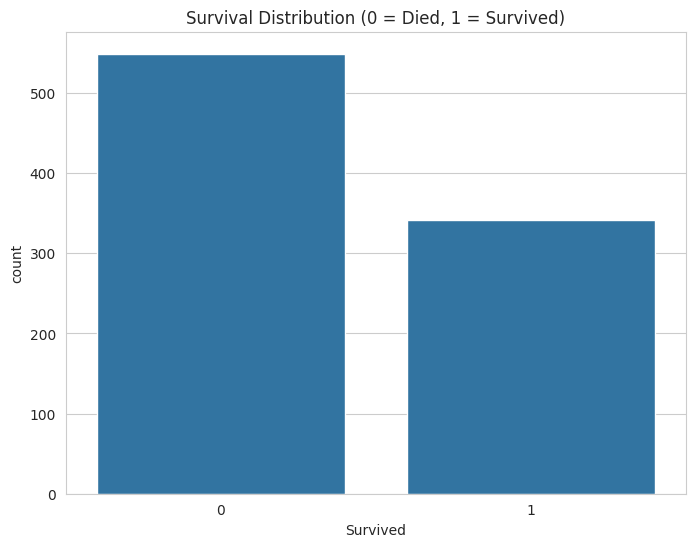

Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.


In [12]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.show()

print("Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.")

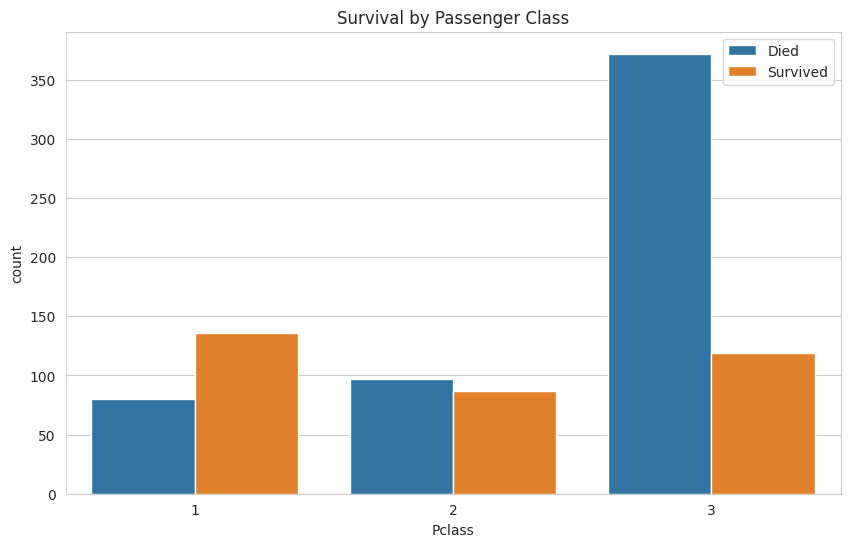

Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.


In [13]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.legend(['Died', 'Survived'])
plt.show()

print("Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.")

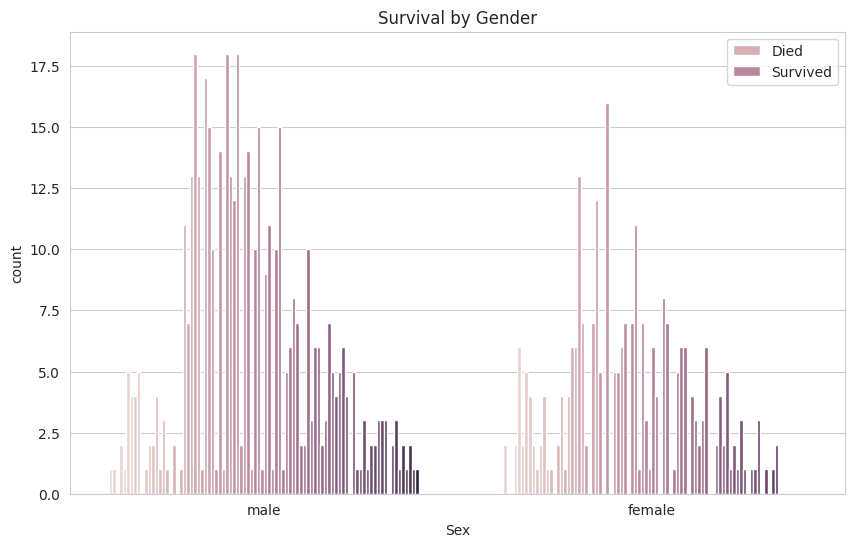

Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.


In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Age', data=df)
plt.title('Survival by Gender')
plt.legend(['Died', 'Survived'])
plt.show()

print("Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.")

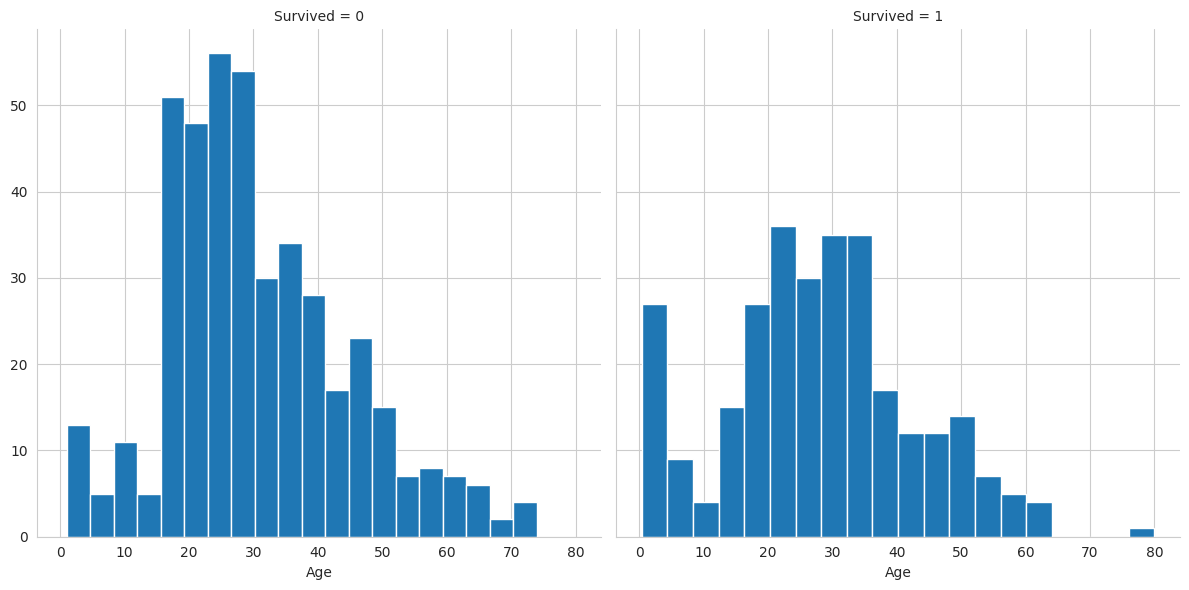

Insight: The age distribution for those who did not survive is centered around the 20-40 age range. For those who survived, there is a noticeable spike for young children. This supports the 'children' part of the mantra.


In [15]:
# A FacetGrid allows us to create multiple plots side-by-side to compare distributions.
# Here, we create one histogram for passengers who died (col='Survived'=0) and one for those who survived (col='Survived'=1).
g = sns.FacetGrid(df, col='Survived', height=6)
g.map(plt.hist, 'Age', bins=20)
plt.show()

print("Insight: The age distribution for those who did not survive is centered around the 20-40 age range. For those who survived, there is a noticeable spike for young children. This supports the 'children' part of the mantra.")

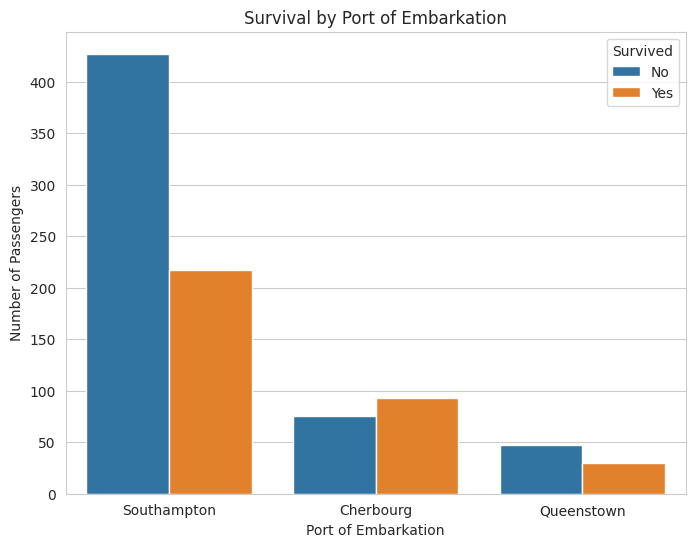

Survival Rates by Port of Embarkation:
Embarked
Cherbourg      55.36
Queenstown     38.96
Southampton    33.70
Name: Survived, dtype: float64


In [18]:
# Experiment 1: Port of Embarkation
embark_df = df.dropna(subset=['Embarked'])
embark_df.loc[:,'Embarked'] = embark_df['Embarked'].map({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})

# Create the countplot
plt.figure(figsize=(8, 6))
sns.countplot(data=embark_df, x='Embarked', hue='Survived')
plt.title('Survival by Port of Embarkation')
plt.xlabel('Port of Embarkation')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

# Display survival rates by embarkation port
survival_rates = embark_df.groupby('Embarked')['Survived'].mean()*100
print("Survival Rates by Port of Embarkation:")
print(survival_rates.round(2))

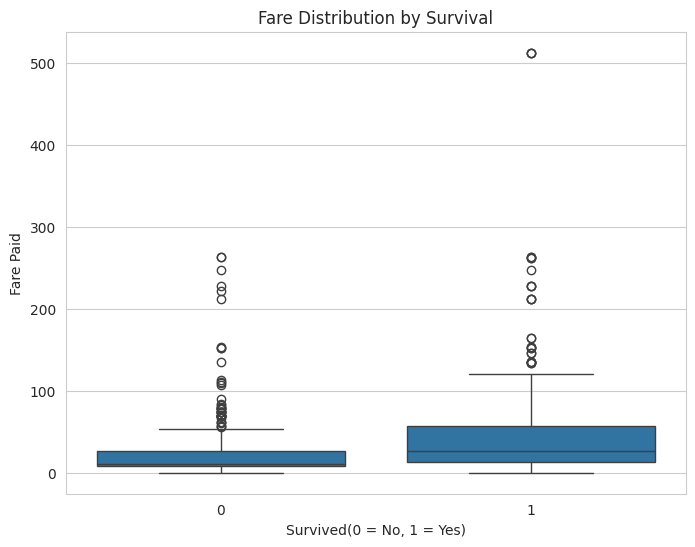

fare__df.groupby('Survived')['Fare'].describe()


In [19]:
# Remove rows with missing values
fare_df = df.dropna(subset=['Fare', 'Survived'])

# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=fare_df, x='Survived', y='Fare')

plt.title('Fare Distribution by Survival')
plt.xlabel('Survived(0 = No, 1 = Yes)')
plt.ylabel('Fare Paid')

plt.show()

# Summary statistics
print("fare__df.groupby('Survived')['Fare'].describe()")

         **KNOWLEDGE CHECK**

  1. What is the primary goal of Exploratory Data Analysis (EDA)?

  The primary goal of EDA is to comprehend a dataset by summarizing the main characteristics, indentifying patterns and relationships, detecting outliers or missing values, and preparing the data for further analysis or machine learning.

  2. Based on the plots in this lab, what kind of person had the best chance of surviving the Titanic? (Describe them in terms of class, gender, and age).

  Based on the plots, the passengers with the best chance of surviving were female, first-class passengers, and younger aldults or children. Women had much higher survival rates than men, first-class passengers survived more often than those in second or third class, and younger passengers generally had a better chance of survival than older passengers.

  3. Why is it important to visualize data instead of just looking at summary statistics? What can a plot show you that a number like 'mean' or 'count' can't?

  Visualizing data is extremely important because it helps show patterns, trends, relationships, outliers, and the distribution of the data that the summary statistics may not reveal. A plot can reveal differences between groups, clusters, skewed distributions, and unusual values, while statistics like the 'mean' or 'count' only provide a limited numerical summary.    